# Euro Area Macro & Markets Analysis

## Project Objective

This project analyzes the relationship between macroeconomic conditions, monetary policy and financial markets in the Euro Area from 2020 onwards.

The analysis focuses on how changes in inflation and ECB monetary policy are associated with movements in European equities, government bond yields and the EUR/USD exchange rate.

The main variables considered are:

- EURO STOXX 50
- Euro Area 10-Year Government Bond Yield
- EUR/USD
- Euro Area HICP Inflation
- ECB Deposit Facility Rate
- Effective Federal Funds Rate

Python is used to collect, clean and combine market and macroeconomic data, calculate returns and risk measures, analyze correlations and visualize the relationships between the main variables.

The analysis is complemented by an event study of selected ECB monetary policy decisions to examine short-term market reactions around major policy announcements.

## Data Sources

The analysis combines market and macroeconomic data from institutional and financial data sources.

| Variable | Source | Frequency |
|---|---|---|
| EURO STOXX 50 | Yahoo Finance | Daily |
| EUR/USD | Yahoo Finance | Daily |
| Euro Area 10-Year Government Bond Yield | ECB Data Portal | Monthly |
| Euro Area HICP Inflation | Eurostat | Monthly |
| ECB Deposit Facility Rate | ECB Data Portal | Daily |
| Effective Federal Funds Rate | FRED / Federal Reserve Bank of New York | Daily |

Daily market and policy-rate series are transformed to monthly frequency where required for the cross-asset analysis, while daily observations are retained for the ECB event study.

**Sample coverage.** Daily market prices are collected from January 2020 through August 2026. The common monthly dataset used for the macroeconomic, performance and cross-asset analysis covers January 2020 through December 2025 (72 monthly observations), because the supplied HICP series ends in December 2025. The event study covers eight selected ECB meetings between 2022 and 2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Market Data

This section collects and prepares market data for the main European financial assets used in the analysis.

The initial focus is on:

- EURO STOXX 50
- EUR/USD

In [2]:
import yfinance as yf

In [3]:
start_date = "2020-01-01"
end_date = "2026-09-01"

In [4]:
eurostoxx = yf.download(
    "^STOXX50E",
    start=start_date,
    end=end_date,
    auto_adjust=True
)
eurostoxx.head()


[*********************100%***********************]  1 of 1 completed

Price,Close,High,Low,Open,Volume
Ticker,^STOXX50E,^STOXX50E,^STOXX50E,^STOXX50E,^STOXX50E
Date,,,,,
2020-01-03,3773.370117,3787.570068,3745.540039,3787.570068,30343400
2020-01-06,3752.520020,3764.340088,3710.939941,3764.340088,28339400
2020-01-07,3759.250000,3784.419922,3748.129883,3760.090088,29853300
2020-01-08,3772.560059,3775.429932,3732.899902,3752.870117,34988400
2020-01-09,3795.879883,3807.090088,3782.770020,3782.770020,33480100


In [ ]:
eurusd = yf.download(
    "EURUSD=X",
    start=start_date,
    end=end_date,
    auto_adjust=True

)
eurusd.head()


[*********************100%***********************]  1 of 1 completed

Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,
2020-01-01,1.122083,1.122838,1.115947,1.122083,0
2020-01-02,1.122083,1.122712,1.116682,1.121894,0
2020-01-03,1.117144,1.118068,1.112570,1.117081,0
2020-01-06,1.116196,1.120825,1.115810,1.116246,0
2020-01-07,1.119799,1.119946,1.113487,1.119583,0


In [6]:
prices = pd.concat(
    [eurostoxx["Close"], eurusd["Close"]],
    axis=1,
    sort=True
)

prices.columns = ["EuroStoxx50", "EURUSD"]

prices.head()

,EuroStoxx50,EURUSD
Date,,
2020-01-01,NaN,1.122083
2020-01-02,NaN,1.122083
2020-01-03,3773.370117,1.117144
2020-01-06,3752.520020,1.116196
2020-01-07,3759.250000,1.119799


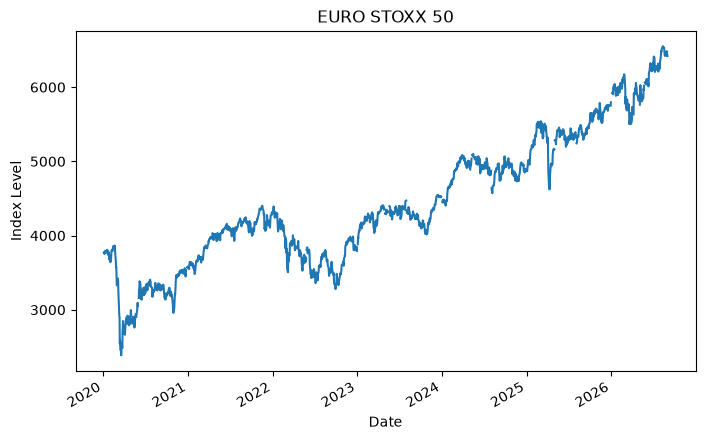

In [7]:
prices["EuroStoxx50"].plot(figsize=(8,5))
plt.title("EURO STOXX 50")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.show()

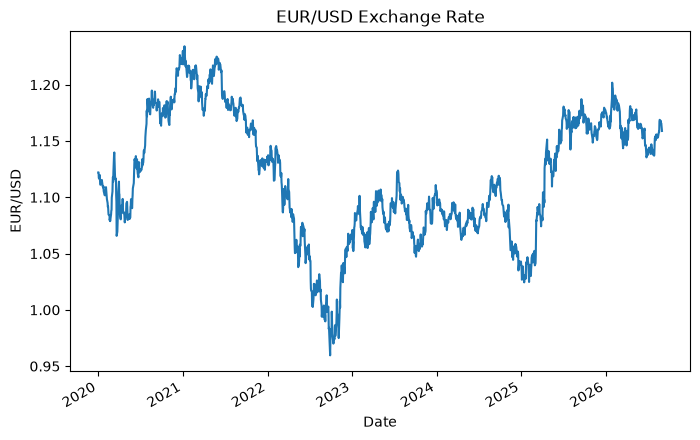

In [8]:
prices["EURUSD"].plot(figsize=(8,5))
plt.title("EUR/USD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("EUR/USD")
plt.show()

In [9]:
monthly_prices = prices.resample("ME").last()
monthly_prices.head()

,EuroStoxx50,EURUSD
Date,,
2020-01-31,3640.909912,1.102913
2020-02-29,3329.489990,1.099723
2020-03-31,2786.899902,1.103047
2020-04-30,2927.929932,1.087725
2020-05-31,3050.199951,1.107911


In [10]:
monthly_returns = monthly_prices.pct_change()
monthly_returns.head()

,EuroStoxx50,EURUSD
Date,,
2020-01-31,NaN,NaN
2020-02-29,-0.085534,-0.002892
2020-03-31,-0.162965,0.003022
2020-04-30,0.050605,-0.013890
2020-05-31,0.041760,0.018558


In [11]:
monthly_returns.columns = [
    "EuroStoxx50_Return",
    "EURUSD_Return"
]
monthly_returns.head()

,EuroStoxx50_Return,EURUSD_Return
Date,,
2020-01-31,NaN,NaN
2020-02-29,-0.085534,-0.002892
2020-03-31,-0.162965,0.003022
2020-04-30,0.050605,-0.013890
2020-05-31,0.041760,0.018558


## 2. Fixed Income Market

This section introduces the 10-year euro-area government benchmark bond yield as a proxy for long-term interest rates in the euro area.

The series is obtained from the ECB Data Portal.

In [12]:
bond_data = pd.read_csv("../data/euro_area_10y_yield.csv")
bond_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 3 columns):
 #   Column                                                                               Non-Null Count  Dtype  
---  ------                                                                               --------------  -----  
 0   DATE                                                                                 680 non-null    str    
 1   TIME PERIOD                                                                          680 non-null    str    
 2   Euro Area 10 Years Government Benchmark Bond - Yield (FM.M.U2.EUR.4F.BB.U2_10Y.YLD)  680 non-null    float64
dtypes: float64(1), str(2)
memory usage: 16.1 KB


In [13]:
bond_data = bond_data[[
    "DATE",
    "Euro Area 10 Years Government Benchmark Bond - Yield (FM.M.U2.EUR.4F.BB.U2_10Y.YLD)"
]].copy()
bond_data.columns = [
    "Date",
    "EuroArea_10Y_Yield"
]
bond_data["Date"] = pd.to_datetime(bond_data["Date"])
bond_data = bond_data.set_index("Date")
bond_data = bond_data.loc["2020-01-01":"2026-08-31"]
bond_data.head()

,EuroArea_10Y_Yield
Date,
2020-01-31,0.315868
2020-02-29,0.132263
2020-03-31,0.372634
2020-04-30,0.553776
2020-05-31,0.479136


In [14]:
bond_data.tail()

,EuroArea_10Y_Yield
Date,
2026-04-30,3.463690
2026-05-31,3.490479
2026-06-30,3.402309
2026-07-31,3.559029
2026-08-31,3.664718


In [15]:
bond_data["EuroArea_10Y_Change"] = bond_data["EuroArea_10Y_Yield"].diff()
bond_data.head()

,EuroArea_10Y_Yield,EuroArea_10Y_Change
Date,,
2020-01-31,0.315868,NaN
2020-02-29,0.132263,-0.183605
2020-03-31,0.372634,0.240372
2020-04-30,0.553776,0.181142
2020-05-31,0.479136,-0.074640


In [16]:
bond_data["EuroArea_10Y_Change_bps"] = bond_data["EuroArea_10Y_Change"] * 100
bond_data.head()

,EuroArea_10Y_Yield,EuroArea_10Y_Change,EuroArea_10Y_Change_bps
Date,,,
2020-01-31,0.315868,NaN,NaN
2020-02-29,0.132263,-0.183605,-18.36048
2020-03-31,0.372634,0.240372,24.03716
2020-04-30,0.553776,0.181142,18.11418
2020-05-31,0.479136,-0.074640,-7.46404


In [17]:
market_data_monthly = pd.concat(
    [monthly_prices, bond_data],
    axis=1,
    join="inner"
)
market_data_monthly.head()

,EuroStoxx50,EURUSD,EuroArea_10Y_Yield,EuroArea_10Y_Change,EuroArea_10Y_Change_bps
Date,,,,,
2020-01-31,3640.909912,1.102913,0.315868,NaN,NaN
2020-02-29,3329.489990,1.099723,0.132263,-0.183605,-18.36048
2020-03-31,2786.899902,1.103047,0.372634,0.240372,24.03716
2020-04-30,2927.929932,1.087725,0.553776,0.181142,18.11418
2020-05-31,3050.199951,1.107911,0.479136,-0.074640,-7.46404


In [18]:
inflation_data = pd.read_csv("../data/euro_area_hicp_inflation.csv")
inflation_data.head()

,DATAFLOW,LAST UPDATE,freq,unit,coicop,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:PRC_HICP_MANR(1.0),06/02/26 23:00:00,Monthly,Annual rate of change,All-items HICP,Euro area – 20 countries (2023-2025),2020-01,1.4,NaN,NaN
1,ESTAT:PRC_HICP_MANR(1.0),06/02/26 23:00:00,Monthly,Annual rate of change,All-items HICP,Euro area – 20 countries (2023-2025),2020-02,1.2,NaN,NaN
2,ESTAT:PRC_HICP_MANR(1.0),06/02/26 23:00:00,Monthly,Annual rate of change,All-items HICP,Euro area – 20 countries (2023-2025),2020-03,0.7,NaN,NaN
3,ESTAT:PRC_HICP_MANR(1.0),06/02/26 23:00:00,Monthly,Annual rate of change,All-items HICP,Euro area – 20 countries (2023-2025),2020-04,0.3,NaN,NaN
4,ESTAT:PRC_HICP_MANR(1.0),06/02/26 23:00:00,Monthly,Annual rate of change,All-items HICP,Euro area – 20 countries (2023-2025),2020-05,0.1,NaN,NaN


In [21]:
inflation_data = inflation_data[[
    "TIME_PERIOD",
    "OBS_VALUE"
]].copy()
inflation_data.columns = [
    "Date",
    "EuroArea_Inflation"
]
inflation_data["Date"] = pd.to_datetime(inflation_data["Date"])
inflation_data = inflation_data.set_index("Date")
inflation_data = inflation_data.loc["2020-01-01":]
inflation_data.head()

,EuroArea_Inflation
Date,
2020-01-01,1.4
2020-02-01,1.2
2020-03-01,0.7
2020-04-01,0.3
2020-05-01,0.1


In [22]:
inflation_data["Inflation_Change"] = (inflation_data["EuroArea_Inflation"].diff())
inflation_data.head()

,EuroArea_Inflation,Inflation_Change
Date,,
2020-01-01,1.4,NaN
2020-02-01,1.2,-0.2
2020-03-01,0.7,-0.5
2020-04-01,0.3,-0.4
2020-05-01,0.1,-0.2


In [23]:
market_data_monthly.index = market_data_monthly.index.to_period("M")
inflation_data.index = inflation_data.index.to_period("M")
macro_market_data = pd.concat(
    [market_data_monthly, inflation_data],
    axis=1,
    join="inner"
)
macro_market_data.head()

,EuroStoxx50,EURUSD,EuroArea_10Y_Yield,EuroArea_10Y_Change,EuroArea_10Y_Change_bps,EuroArea_Inflation,Inflation_Change
Date,,,,,,,
2020-01,3640.909912,1.102913,0.315868,NaN,NaN,1.4,NaN
2020-02,3329.489990,1.099723,0.132263,-0.183605,-18.36048,1.2,-0.2
2020-03,2786.899902,1.103047,0.372634,0.240372,24.03716,0.7,-0.5
2020-04,2927.929932,1.087725,0.553776,0.181142,18.11418,0.3,-0.4
2020-05,3050.199951,1.107911,0.479136,-0.074640,-7.46404,0.1,-0.2


In [24]:
ecb_rate = pd.read_csv("../data/ecb_deposit_facility_rate.csv")
ecb_rate.head()

,DATE,TIME PERIOD,Deposit facility - date of changes (raw data) - Level (FM.D.U2.EUR.4F.KR.DFR.LEV)
0,1999-01-01,01 Jan 1999,2.00
1,1999-01-02,02 Jan 1999,2.00
2,1999-01-03,03 Jan 1999,2.00
3,1999-01-04,04 Jan 1999,2.75
4,1999-01-05,05 Jan 1999,2.75


In [25]:
ecb_rate = ecb_rate[[
    "DATE",
    "Deposit facility - date of changes (raw data) - Level (FM.D.U2.EUR.4F.KR.DFR.LEV)"
]].copy()
ecb_rate.head()

,DATE,Deposit facility - date of changes (raw data) - Level (FM.D.U2.EUR.4F.KR.DFR.LEV)
0,1999-01-01,2.00
1,1999-01-02,2.00
2,1999-01-03,2.00
3,1999-01-04,2.75
4,1999-01-05,2.75


In [26]:
ecb_rate.columns = [
    "Date",
    "ECB_Deposit_Rate"
]
ecb_rate["Date"] = pd.to_datetime(ecb_rate["Date"])
ecb_rate = ecb_rate.set_index("Date")
ecb_rate = ecb_rate.loc["2020-01-01":]
ecb_rate_monthly = ecb_rate.resample("ME").last()
ecb_rate_monthly.head()

,ECB_Deposit_Rate
Date,
2020-01-31,-0.5
2020-02-29,-0.5
2020-03-31,-0.5
2020-04-30,-0.5
2020-05-31,-0.5


In [27]:
ecb_rate_monthly.index = ecb_rate_monthly.index.to_period("M")
macro_market_data = pd.concat(
    [macro_market_data, ecb_rate_monthly],
    axis=1,
    join="inner"
)
macro_market_data.head()

,EuroStoxx50,EURUSD,EuroArea_10Y_Yield,EuroArea_10Y_Change,EuroArea_10Y_Change_bps,EuroArea_Inflation,Inflation_Change,ECB_Deposit_Rate
Date,,,,,,,,
2020-01,3640.909912,1.102913,0.315868,NaN,NaN,1.4,NaN,-0.5
2020-02,3329.489990,1.099723,0.132263,-0.183605,-18.36048,1.2,-0.2,-0.5
2020-03,2786.899902,1.103047,0.372634,0.240372,24.03716,0.7,-0.5,-0.5
2020-04,2927.929932,1.087725,0.553776,0.181142,18.11418,0.3,-0.4,-0.5
2020-05,3050.199951,1.107911,0.479136,-0.074640,-7.46404,0.1,-0.2,-0.5


In [28]:
macro_market_data["EuroStoxx50_Return"] = (macro_market_data["EuroStoxx50"].pct_change())
macro_market_data["EURUSD_Return"] = (macro_market_data["EURUSD"].pct_change())

In [29]:
macro_market_data[[
    "EuroStoxx50",
    "EuroStoxx50_Return",
    "EURUSD",
    "EURUSD_Return"
]].head()

,EuroStoxx50,EuroStoxx50_Return,EURUSD,EURUSD_Return
Date,,,,
2020-01,3640.909912,NaN,1.102913,NaN
2020-02,3329.489990,-0.085534,1.099723,-0.002892
2020-03,2786.899902,-0.162965,1.103047,0.003022
2020-04,2927.929932,0.050605,1.087725,-0.013890
2020-05,3050.199951,0.041760,1.107911,0.018558


In [31]:
annualized_return = (
    macro_market_data["EuroStoxx50_Return"].mean() * 12
)
annualized_return

np.float64(0.09458135573252702)

In [32]:
annualized_volatility = (
    macro_market_data["EuroStoxx50_Return"].std() * (12 ** 0.5)
)
annualized_volatility

np.float64(0.17895168629442673)

In [33]:
macro_market_data["EuroStoxx50_Peak"] = (macro_market_data["EuroStoxx50"].cummax())
macro_market_data["EuroStoxx50_Drawdown"] = (macro_market_data["EuroStoxx50"]/ macro_market_data["EuroStoxx50_Peak"] - 1)
macro_market_data["EuroStoxx50_Drawdown"]

Date
2020-01    0.000000
2020-02   -0.085534
2020-03   -0.234560
2020-04   -0.195825
2020-05   -0.162242
             ...   
2025-08   -0.020465
2025-09    0.000000
2025-10    0.000000
2025-11    0.000000
2025-12    0.000000
Freq: M, Name: EuroStoxx50_Drawdown, Length: 72, dtype: float64

In [34]:
max_drawdown = (
    macro_market_data["EuroStoxx50_Drawdown"].min()
)
print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -23.46%


In [35]:
max_drawdown_date = (
    macro_market_data["EuroStoxx50_Drawdown"].idxmin()
)
max_drawdown_date

Period('2020-03', 'M')

In [36]:
macro_market_data[[
    "EuroStoxx50",
    "EuroStoxx50_Peak",
    "EuroStoxx50_Drawdown"
]].head(10)

,EuroStoxx50,EuroStoxx50_Peak,EuroStoxx50_Drawdown
Date,,,
2020-01,3640.909912,3640.909912,0.000000
2020-02,3329.489990,3640.909912,-0.085534
2020-03,2786.899902,3640.909912,-0.234560
2020-04,2927.929932,3640.909912,-0.195825
2020-05,3050.199951,3640.909912,-0.162242
2020-06,3234.070068,3640.909912,-0.111741
2020-07,3174.320068,3640.909912,-0.128152
2020-08,3272.510010,3640.909912,-0.101183
2020-09,3193.610107,3640.909912,-0.122854


In [37]:
performance_summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Maximum Drawdown"
    ],
    "EuroStoxx50": [
        annualized_return*100,
        annualized_volatility*100,
        max_drawdown*100
    ]
})
performance_summary

,Metric,EuroStoxx50
0,Annualized Return,9.458136
1,Annualized Volatility,17.895169
2,Maximum Drawdown,-23.455950


### Performance and Risk Analysis

Over the common monthly sample from January 2020 to December 2025, the EURO STOXX 50 generated an annualized return of approximately **9.5%**, with an annualized volatility of around **17.9%**.

The maximum drawdown was approximately **-23.5%**, indicating that at its largest decline the index lost almost one quarter of its value relative to its previous peak.

These results highlight the trade-off between return and risk in European equities: the index delivered positive annualized performance over the analyzed period, but investors were exposed to significant fluctuations and periods of substantial market losses.

In [38]:
macro_market_data["ECB_Rate_Change"] = (
    macro_market_data["ECB_Deposit_Rate"].diff()
)
correlation_data = macro_market_data[[
    "EuroStoxx50_Return",
    "EURUSD_Return",
    "EuroArea_10Y_Change_bps",
    "Inflation_Change",
    "ECB_Rate_Change"
]]

correlation_matrix = correlation_data.corr()
correlation_matrix.round(2)

,EuroStoxx50_Return,EURUSD_Return,EuroArea_10Y_Change_bps,Inflation_Change,ECB_Rate_Change
EuroStoxx50_Return,1.00,0.24,-0.32,-0.05,0.06
EURUSD_Return,0.24,1.00,-0.29,-0.20,-0.05
EuroArea_10Y_Change_bps,-0.32,-0.29,1.00,0.18,0.11
Inflation_Change,-0.05,-0.20,0.18,1.00,-0.23
ECB_Rate_Change,0.06,-0.05,0.11,-0.23,1.00


### Correlation Analysis

The correlation matrix examines the relationships between monthly movements in the main macroeconomic and financial variables included in the analysis.

Returns are used for the EURO STOXX 50 and EUR/USD, while changes are considered for government bond yields, inflation and the ECB Deposit Facility Rate. This makes the variables more comparable by focusing on how they move from one month to the next rather than on their absolute levels.

Correlation coefficients range from **-1 to +1**. Positive values indicate that two variables tend to move in the same direction, while negative values indicate that they tend to move in opposite directions. Values close to zero suggest a weak linear relationship.

These correlations should not be interpreted as evidence of causality, since financial markets are influenced by multiple factors simultaneously.

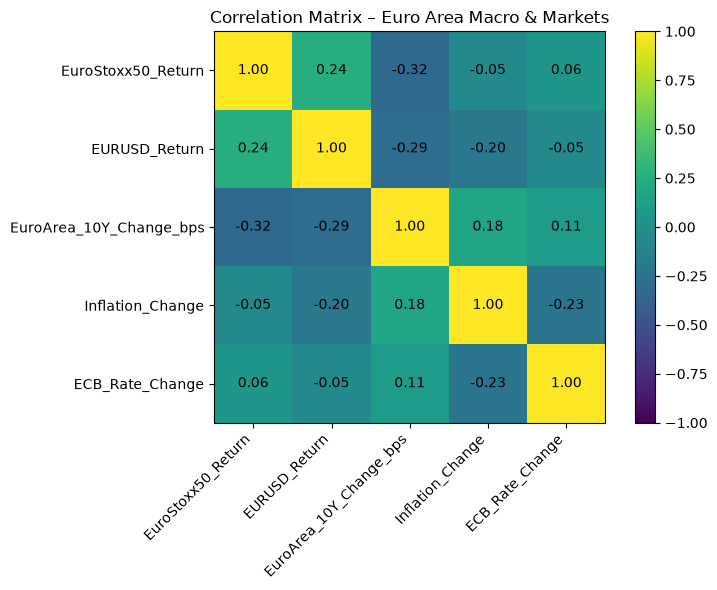

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(im, ax=ax)

ax.set_title(
    "Correlation Matrix – Euro Area Macro & Markets"
)

plt.tight_layout()
plt.show()

In [40]:
macro_market_data["Rolling_Corr_12M"] = (
    macro_market_data["EuroStoxx50_Return"]
    .rolling(window=12)
    .corr(macro_market_data["EuroArea_10Y_Change_bps"])
)

In [41]:
macro_market_data[[
    "EuroStoxx50_Return",
    "EuroArea_10Y_Change_bps",
    "Rolling_Corr_12M"
]].head(15)

,EuroStoxx50_Return,EuroArea_10Y_Change_bps,Rolling_Corr_12M
Date,,,
2020-01,NaN,NaN,NaN
2020-02,-0.085534,-18.36048,NaN
2020-03,-0.162965,24.03716,NaN
2020-04,0.050605,18.11418,NaN
2020-05,0.041760,-7.46404,NaN
2020-06,0.060281,-12.76764,NaN
2020-07,-0.018475,-13.05740,NaN
2020-08,0.030933,-6.08133,NaN
2020-09,-0.024110,-3.66083,NaN


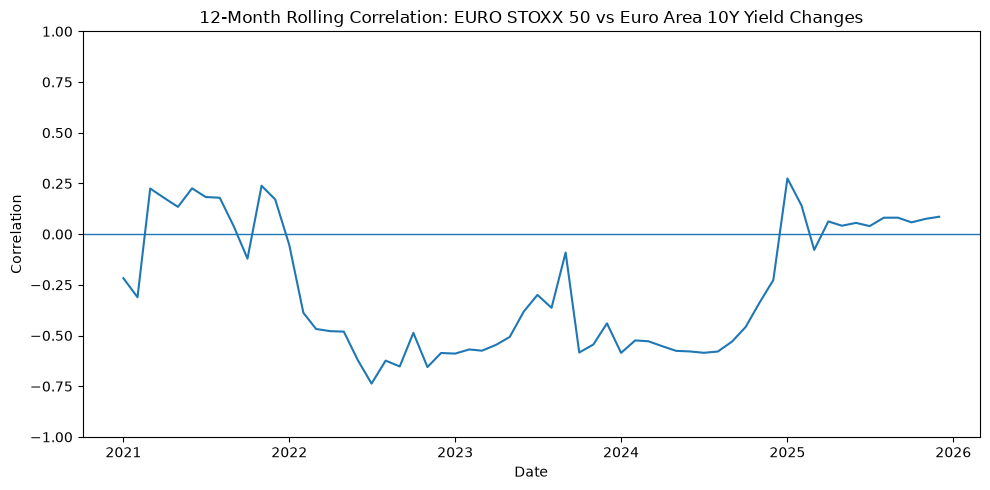

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["Rolling_Corr_12M"]
)
ax.axhline(
    y=0,
    linewidth=1
)
ax.set_title(
    "12-Month Rolling Correlation: EURO STOXX 50 vs Euro Area 10Y Yield Changes"
)
ax.set_ylabel("Correlation")
ax.set_xlabel("Date")

ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

### Rolling Correlation Analysis

A 12-month rolling correlation is used to examine how the relationship between EURO STOXX 50 returns and changes in Euro Area 10-year government bond yields evolved over time.

Unlike the full-period correlation matrix, which provides a single coefficient for the entire sample, the rolling correlation is recalculated using the previous 12 months of observations at each point in time.

This allows us to identify periods in which equity returns and bond yield changes moved more strongly in the same direction or in opposite directions, highlighting how the relationship between the two asset classes can change across different macroeconomic and monetary policy environments.

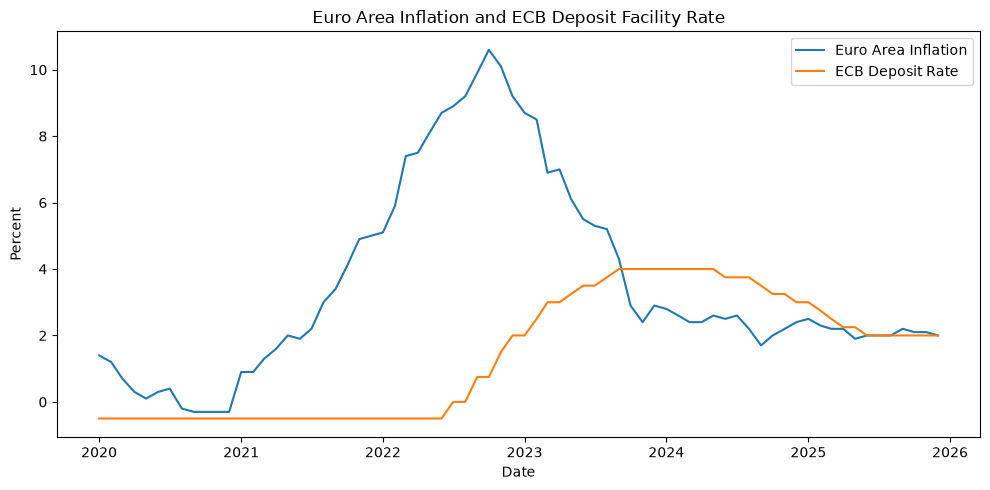

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["EuroArea_Inflation"],
    label="Euro Area Inflation"
)

ax.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["ECB_Deposit_Rate"],
    label="ECB Deposit Rate"
)

ax.set_title(
    "Euro Area Inflation and ECB Deposit Facility Rate"
)

ax.set_ylabel("Percent")
ax.set_xlabel("Date")

ax.legend()

plt.tight_layout()
plt.show()

### Inflation and ECB Monetary Policy

Inflation is one of the main variables considered by the ECB when setting monetary policy.

This chart compares Euro Area HICP inflation with the ECB Deposit Facility Rate from 2020 onwards. This allows us to observe how monetary policy evolved in response to the sharp increase in inflation and its subsequent decline.

The comparison is particularly useful for identifying the timing of the ECB tightening cycle and the lag between changes in inflation and monetary policy decisions.

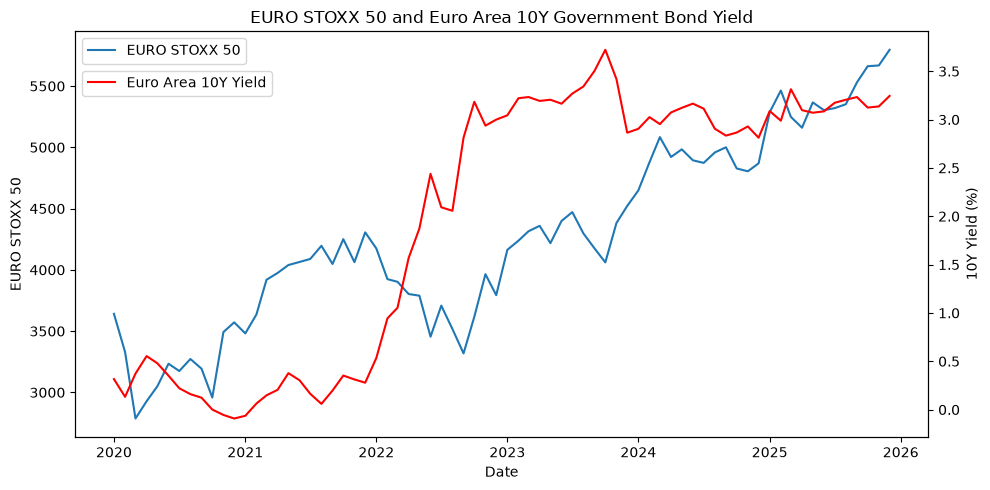

In [44]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["EuroStoxx50"],
    label="EURO STOXX 50"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("EURO STOXX 50")

ax2 = ax1.twinx()

ax2.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["EuroArea_10Y_Yield"],
    color="red",
    label="Euro Area 10Y Yield"
)

ax2.set_ylabel("10Y Yield (%)")

ax1.set_title(
    "EURO STOXX 50 and Euro Area 10Y Government Bond Yield"
)

ax1.legend(loc="upper left")
ax2.legend(loc="upper left", bbox_to_anchor=(0, 0.92))

plt.tight_layout()
plt.show()

### European Equities and Government Bond Yields

The chart compares the EURO STOXX 50 with the Euro Area 10-year government bond yield.

Government bond yields are an important transmission channel of monetary policy. Changes in interest-rate expectations and financial conditions can affect longer-term yields, which in turn influences the discount rates used to value equities and the relative attractiveness of bonds compared with stocks.

The comparison therefore provides a first visual assessment of how European equity prices and long-term interest rates evolved across different monetary policy environments.

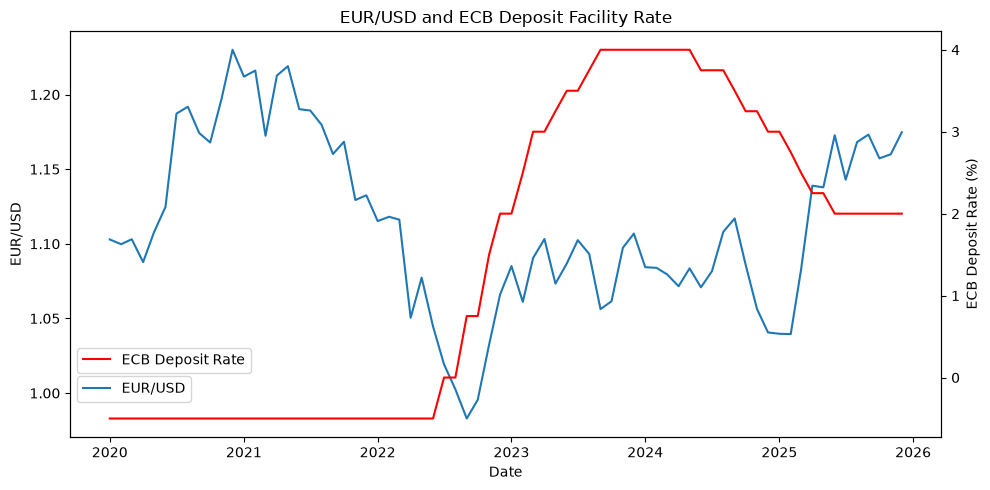

In [45]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["EURUSD"],
    label="EUR/USD"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("EUR/USD")

ax2 = ax1.twinx()

ax2.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["ECB_Deposit_Rate"],
    label="ECB Deposit Rate", color="red"
)

ax2.set_ylabel("ECB Deposit Rate (%)")

ax1.set_title(
    "EUR/USD and ECB Deposit Facility Rate"
)

ax1.legend(loc="lower left", bbox_to_anchor=(0,0.07))
ax2.legend(loc="lower left", bbox_to_anchor=(0, 0.14))

plt.tight_layout()
plt.show()

### EUR/USD and the ECB Deposit Facility Rate

The following chart compares the EUR/USD exchange rate with the ECB Deposit Facility Rate.

ECB monetary policy can influence the euro through changes in interest rates and market expectations. Higher interest rates can increase the relative attractiveness of euro-denominated assets, potentially supporting the euro, while lower rates may have the opposite effect.

However, EUR/USD is a relative exchange rate and therefore cannot be explained by ECB monetary policy alone. Federal Reserve policy, interest-rate expectations, economic growth, inflation and changes in global risk sentiment can also significantly affect the exchange rate.

For this reason, the analysis is subsequently extended by considering the interest-rate differential between the ECB and the Federal Reserve.

In [46]:
fed_rate = pd.read_csv("../data/fed_funds_rate.csv")
fed_rate.head()

,observation_date,EFFR
0,2020-01-02,1.55
1,2020-01-03,1.55
2,2020-01-06,1.55
3,2020-01-07,1.55
4,2020-01-08,1.55


In [47]:
fed_rate.columns

Index(['observation_date', 'EFFR'], dtype='str')

In [48]:
fed_rate = fed_rate[["observation_date","EFFR"]].copy()

fed_rate.columns = ["Date","Fed_Funds_Rate"]

In [49]:
fed_rate["Date"] = pd.to_datetime(fed_rate["Date"])
fed_rate = fed_rate.set_index("Date")

In [50]:
fed_rate = fed_rate.loc["2020-01-01":]

In [51]:
fed_rate_monthly = fed_rate.resample("ME").last()
fed_rate_monthly.head()

,Fed_Funds_Rate
Date,
2020-01-31,1.59
2020-02-29,1.58
2020-03-31,0.08
2020-04-30,0.05
2020-05-31,0.05


In [52]:
fed_rate_monthly.index = (fed_rate_monthly.index.to_period("M"))
macro_market_data = pd.concat(
    [macro_market_data, fed_rate_monthly],
    axis=1,
    join="inner"
)
macro_market_data.head()

,EuroStoxx50,EURUSD,EuroArea_10Y_Yield,EuroArea_10Y_Change,EuroArea_10Y_Change_bps,EuroArea_Inflation,Inflation_Change,ECB_Deposit_Rate,EuroStoxx50_Return,EURUSD_Return,EuroStoxx50_Peak,EuroStoxx50_Drawdown,ECB_Rate_Change,Rolling_Corr_12M,Fed_Funds_Rate
Date,,,,,,,,,,,,,,,
2020-01,3640.909912,1.102913,0.315868,NaN,NaN,1.4,NaN,-0.5,NaN,NaN,3640.909912,0.000000,NaN,NaN,1.59
2020-02,3329.489990,1.099723,0.132263,-0.183605,-18.36048,1.2,-0.2,-0.5,-0.085534,-0.002892,3640.909912,-0.085534,0.0,NaN,1.58
2020-03,2786.899902,1.103047,0.372634,0.240372,24.03716,0.7,-0.5,-0.5,-0.162965,0.003022,3640.909912,-0.234560,0.0,NaN,0.08
2020-04,2927.929932,1.087725,0.553776,0.181142,18.11418,0.3,-0.4,-0.5,0.050605,-0.013890,3640.909912,-0.195825,0.0,NaN,0.05
2020-05,3050.199951,1.107911,0.479136,-0.074640,-7.46404,0.1,-0.2,-0.5,0.041760,0.018558,3640.909912,-0.162242,0.0,NaN,0.05


In [53]:
macro_market_data.tail()

,EuroStoxx50,EURUSD,EuroArea_10Y_Yield,EuroArea_10Y_Change,EuroArea_10Y_Change_bps,EuroArea_Inflation,Inflation_Change,ECB_Deposit_Rate,EuroStoxx50_Return,EURUSD_Return,EuroStoxx50_Peak,EuroStoxx50_Drawdown,ECB_Rate_Change,Rolling_Corr_12M,Fed_Funds_Rate
Date,,,,,,,,,,,,,,,
2025-08,5351.729980,1.168156,3.205046,0.031483,3.14827,2.0,0.0,2.0,0.005979,0.022066,5463.540039,-0.020465,0.0,0.080982,4.33
2025-09,5529.959961,1.173144,3.233046,0.028001,2.80005,2.2,0.2,2.0,0.033303,0.004270,5529.959961,0.000000,0.0,0.081207,4.09
2025-10,5662.040039,1.157247,3.124067,-0.108979,-10.89788,2.1,-0.1,2.0,0.023884,-0.013551,5662.040039,0.000000,0.0,0.058167,3.86
2025-11,5668.169922,1.159985,3.136283,0.012215,1.22151,2.1,0.0,2.0,0.001083,0.002366,5668.169922,0.000000,0.0,0.075363,3.89
2025-12,5796.220215,1.174729,3.244733,0.108450,10.84501,2.0,-0.1,2.0,0.022591,0.012711,5796.220215,0.000000,0.0,0.085788,3.64


In [54]:
macro_market_data["Rate_Differential"] = (
    macro_market_data["ECB_Deposit_Rate"]
    - macro_market_data["Fed_Funds_Rate"]
)

macro_market_data[[
    "ECB_Deposit_Rate",
    "Fed_Funds_Rate",
    "Rate_Differential"
]].head()

,ECB_Deposit_Rate,Fed_Funds_Rate,Rate_Differential
Date,,,
2020-01,-0.5,1.59,-2.09
2020-02,-0.5,1.58,-2.08
2020-03,-0.5,0.08,-0.58
2020-04,-0.5,0.05,-0.55
2020-05,-0.5,0.05,-0.55


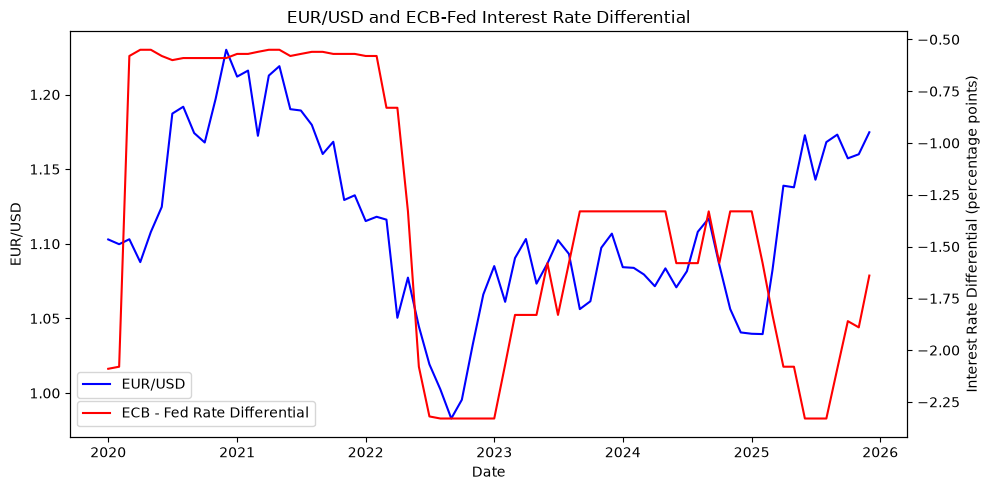

In [55]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["EURUSD"],
    color='blue',
    label="EUR/USD"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("EUR/USD")

ax2 = ax1.twinx()

ax2.plot(
    macro_market_data.index.to_timestamp(),
    macro_market_data["Rate_Differential"],
    color='red',
    label="ECB - Fed Rate Differential"
)

ax2.set_ylabel("Interest Rate Differential (percentage points)")

ax1.set_title(
    "EUR/USD and ECB-Fed Interest Rate Differential"
)

ax1.legend(loc="lower left", bbox_to_anchor=(0,0.08))
ax2.legend(loc="lower left", bbox_to_anchor=(0, 0.009))

plt.tight_layout()
plt.show()

### EUR/USD and the ECB-Fed Interest Rate Differential

Interest-rate differentials are an important factor in foreign-exchange markets because they affect the relative return offered by assets denominated in different currencies.

In this case it compares EUR/USD with the difference between the ECB Deposit Facility Rate and the Effective Federal Funds Rate.

A positive differential indicates that the ECB policy rate is above the Federal Reserve rate, while a negative differential indicates that the Federal Reserve rate is higher. Comparing this differential with EUR/USD helps assess whether changes in the relative monetary policy stance of the ECB and the Federal Reserve are associated with movements in the euro.

In [56]:
macro_market_data["Rate_Differential_Change"] = (
    macro_market_data["Rate_Differential"].diff()
)
macro_market_data[
    ["ECB_Deposit_Rate",
     "Fed_Funds_Rate",
     "Rate_Differential",
     "Rate_Differential_Change"]
].head(10)

,ECB_Deposit_Rate,Fed_Funds_Rate,Rate_Differential,Rate_Differential_Change
Date,,,,
2020-01,-0.5,1.59,-2.09,NaN
2020-02,-0.5,1.58,-2.08,0.01
2020-03,-0.5,0.08,-0.58,1.50
2020-04,-0.5,0.05,-0.55,0.03
2020-05,-0.5,0.05,-0.55,0.00
2020-06,-0.5,0.08,-0.58,-0.03
2020-07,-0.5,0.10,-0.60,-0.02
2020-08,-0.5,0.09,-0.59,0.01
2020-09,-0.5,0.09,-0.59,0.00


In [57]:
macro_market_data[
    ["EURUSD_Return", "Rate_Differential_Change"]
].corr()

,EURUSD_Return,Rate_Differential_Change
EURUSD_Return,1.000000,-0.042162
Rate_Differential_Change,-0.042162,1.000000


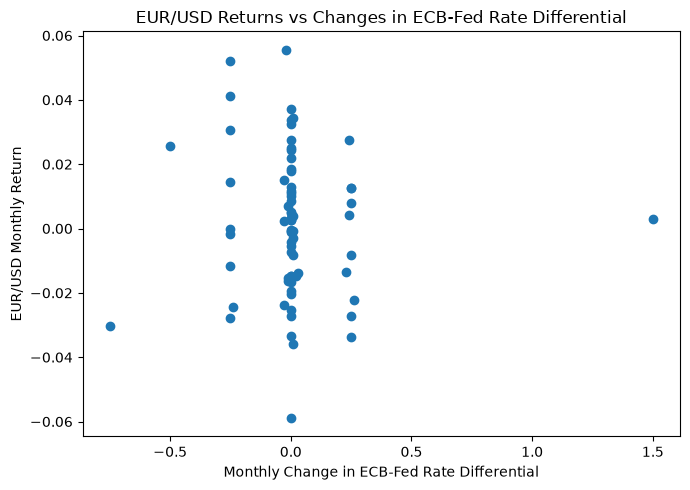

In [58]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    macro_market_data["Rate_Differential_Change"],
    macro_market_data["EURUSD_Return"]
)

ax.set_xlabel(
    "Monthly Change in ECB-Fed Rate Differential"
)

ax.set_ylabel(
    "EUR/USD Monthly Return"
)

ax.set_title(
    "EUR/USD Returns vs Changes in ECB-Fed Rate Differential"
)

plt.tight_layout()
plt.show()

### EUR/USD Returns and Changes in the Interest Rate Differential

To examine the relationship more directly, monthly EUR/USD returns are compared with monthly changes in the ECB-Fed interest-rate differential.

Using changes rather than the level of the differential makes the comparison more consistent with exchange-rate returns, as both variables measure movements from one month to the next.

The scatter plot provides a visual representation of the relationship between the two variables. A clear upward or downward pattern would suggest a stronger linear relationship, while widely dispersed observations would indicate that other factors also play an important role in EUR/USD movements.

In [59]:
macro_market_data.to_csv("../data/macro_market_data.csv")


## ECB Monetary Policy Event Study

### Objective

The objective of this event study is to analyze short-term financial market reactions around selected ECB monetary policy decisions.

The analysis focuses on two key market variables:

- **EURO STOXX 50**, representing European equity markets
- **EUR/USD**, representing the reaction of the euro against the US dollar

Eight major ECB monetary policy meetings between 2022 and 2024 are selected, covering the main phases of the ECB tightening and subsequent easing cycle.

The analysis focuses on raw cumulative market returns around ECB announcements rather than abnormal returns relative to an estimated market benchmark. Therefore, the results should be interpreted as short-term market movements around ECB decisions rather than as causal estimates of the impact of monetary policy.

In [60]:
ecb_events = pd.DataFrame({
    "Date": [
        "2022-07-21",
        "2022-09-08",
        "2022-10-27",
        "2022-12-15",
        "2023-03-16",
        "2023-09-14",
        "2024-06-06",
        "2024-09-12"
    ],

    "Rate_Change_bps": [
        50,
        75,
        75,
        50,
        50,
        25,
        -25,
        -25
    ],

    "Event": [
        "First rate hike of the tightening cycle",
        "75 bp acceleration in monetary tightening",
        "Third consecutive major rate increase",
        "Slower 50 bp hike, but restrictive guidance",
        "50 bp hike amid financial market tensions",
        "Final hike of the tightening cycle",
        "First rate cut after nine months on hold",
        "Second 25 bp cut"
    ]
})

ecb_events["Date"] = pd.to_datetime(ecb_events["Date"])

ecb_events

,Date,Rate_Change_bps,Event
0,2022-07-21,50,First rate hike of the tightening cycle
1,2022-09-08,75,75 bp acceleration in monetary tightening
2,2022-10-27,75,Third consecutive major rate increase
3,2022-12-15,50,"Slower 50 bp hike, but restrictive guidance"
4,2023-03-16,50,50 bp hike amid financial market tensions
5,2023-09-14,25,Final hike of the tightening cycle
6,2024-06-06,-25,First rate cut after nine months on hold
7,2024-09-12,-25,Second 25 bp cut


In [61]:
event_eurostoxx = yf.download(
    "^STOXX50E",
    start="2022-01-01",
    end="2024-10-01",
    auto_adjust=True
)

event_eurusd = yf.download(
    "EURUSD=X",
    start="2022-01-01",
    end="2024-10-01",
    auto_adjust=True
)


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

In [62]:
event_eurostoxx_close = event_eurostoxx["Close"].squeeze()
event_eurusd_close = event_eurusd["Close"].squeeze()

event_market_data = pd.concat(
    [event_eurostoxx_close, event_eurusd_close],
    axis=1,
    sort=True
)
event_market_data.columns = [
    "EuroStoxx50",
    "EURUSD"
]

event_market_data.head()

,EuroStoxx50,EURUSD
Date,,
2022-01-03,4331.819824,1.137346
2022-01-04,4367.620117,1.130224
2022-01-05,4392.149902,1.128363
2022-01-06,4324.810059,1.131350
2022-01-07,4305.830078,1.129688


## Measuring the market reaction around ECB decisions

For each selected ECB meeting, we identify the corresponding trading day in the daily market dataset.

We measure daily returns for the EURO STOXX 50 and EUR/USD over a three-day window covering the trading day before the ECB announcement, the announcement day and the following trading day.

Compounding these daily returns provides the cumulative market movement around each decision.

In [63]:
event_market_data["EuroStoxx50_Return"] = (
    event_market_data["EuroStoxx50"].pct_change()
)

event_market_data["EURUSD_Return"] = (
    event_market_data["EURUSD"].pct_change()
)
event_market_data.head()

,EuroStoxx50,EURUSD,EuroStoxx50_Return,EURUSD_Return
Date,,,,
2022-01-03,4331.819824,1.137346,NaN,NaN
2022-01-04,4367.620117,1.130224,0.008264,-0.006261
2022-01-05,4392.149902,1.128363,0.005616,-0.001647
2022-01-06,4324.810059,1.131350,-0.015332,0.002647
2022-01-07,4305.830078,1.129688,-0.004389,-0.001469


### Event window

To capture the short-term market reaction around each ECB announcement, a three-day event window is used:

- **Day -1**: trading day before the ECB decision
- **Day 0**: ECB announcement day
- **Day +1**: following trading day

This allows us to observe whether markets started moving before the announcement and whether the reaction continued after the decision.

In [64]:
event_results = []

for _, event in ecb_events.iterrows():

    event_date = event["Date"]

    if event_date in event_market_data.index:

        position = event_market_data.index.get_loc(event_date)

        previous_day = event_market_data.iloc[position - 1]
        event_day = event_market_data.iloc[position]
        next_day = event_market_data.iloc[position + 1]

        event_results.append({

            "Date": event_date,

            "Rate_Change_bps":
                event["Rate_Change_bps"],

            "Event":
                event["Event"],

            "EuroStoxx50_Day_-1_%":
                previous_day["EuroStoxx50_Return"] * 100,

            "EuroStoxx50_Day_0_%":
                event_day["EuroStoxx50_Return"] * 100,

            "EuroStoxx50_Day_+1_%":
                next_day["EuroStoxx50_Return"] * 100,

            "EURUSD_Day_-1_%":
                previous_day["EURUSD_Return"] * 100,

            "EURUSD_Day_0_%":
                event_day["EURUSD_Return"] * 100,

            "EURUSD_Day_+1_%":
                next_day["EURUSD_Return"] * 100
        })


event_study = pd.DataFrame(event_results)

event_study

,Date,Rate_Change_bps,Event,EuroStoxx50_Day_-1_%,EuroStoxx50_Day_0_%,EuroStoxx50_Day_+1_%,EURUSD_Day_-1_%,EURUSD_Day_0_%,EURUSD_Day_+1_%
0,2022-07-21,50,First rate hike of the tightening cycle,-0.061324,0.314345,-0.000557,0.849197,-0.474515,0.376133
1,2022-09-08,75,75 bp acceleration in monetary tightening,0.055718,0.293819,1.641626,-0.545389,0.987582,0.163202
2,2022-10-27,75,Third consecutive major rate increase,0.550259,-0.022191,0.236093,0.781145,1.286733,-1.230030
3,2022-12-15,50,"Slower 50 bp hike, but restrictive guidance",-0.290207,-3.510715,-0.825923,0.805502,0.467632,-0.335184
4,2023-03-16,50,50 bp hike amid financial market tensions,-3.458579,2.033747,-1.262819,0.024675,-1.345148,0.290833
5,2023-09-14,25,Final hike of the tightening cycle,-0.442924,1.332314,0.357493,0.026890,-0.177119,-0.904157
6,2024-06-06,-25,First rate cut after nine months on hold,1.661294,0.663859,-0.350749,-0.233962,-0.067416,0.183015
7,2024-09-12,-25,Second 25 bp cut,0.345043,1.060127,0.621306,-0.149887,-0.091389,0.608177


In [65]:
event_study["EuroStoxx50_Cumulative_%"] = (
    (
        1 + event_study[[
            "EuroStoxx50_Day_-1_%",
            "EuroStoxx50_Day_0_%",
            "EuroStoxx50_Day_+1_%"
        ]] / 100
    ).prod(axis=1) - 1
) * 100

event_study["EURUSD_Cumulative_%"] = (
    (
        1 + event_study[[
            "EURUSD_Day_-1_%",
            "EURUSD_Day_0_%",
            "EURUSD_Day_+1_%"
        ]] / 100
    ).prod(axis=1) - 1
) * 100

In [66]:
event_study[[
    "Date",
    "Rate_Change_bps",
    "Event",
    "EuroStoxx50_Cumulative_%",
    "EURUSD_Cumulative_%"
]]

,Date,Rate_Change_bps,Event,EuroStoxx50_Cumulative_%,EURUSD_Cumulative_%
0,2022-07-21,50,First rate hike of the tightening cycle,0.252270,0.748179
1,2022-09-08,75,75 bp acceleration in monetary tightening,1.997067,0.600722
2,2022-10-27,75,Third consecutive major rate increase,0.765286,0.822341
3,2022-12-15,50,"Slower 50 bp hike, but restrictive guidance",-4.585349,0.937437
4,2023-03-16,50,50 bp hike amid financial market tensions,-2.739109,-1.033813
5,2023-09-14,25,Final hike of the tightening cycle,1.244140,-1.053075
6,2024-06-06,-25,First rate cut after nine months on hold,1.977239,-0.118757
7,2024-09-12,-25,Second 25 bp cut,2.038887,0.365571


### Comparing cumulative market reactions

The cumulative returns allow us to compare the overall market reaction associated with each selected ECB meeting.

A positive value indicates that the asset appreciated over the three-day event window, while a negative value indicates a decline.

Comparing the reactions across different meetings helps identify which ECB decisions coincided with the strongest short-term movements in European equities and the euro.

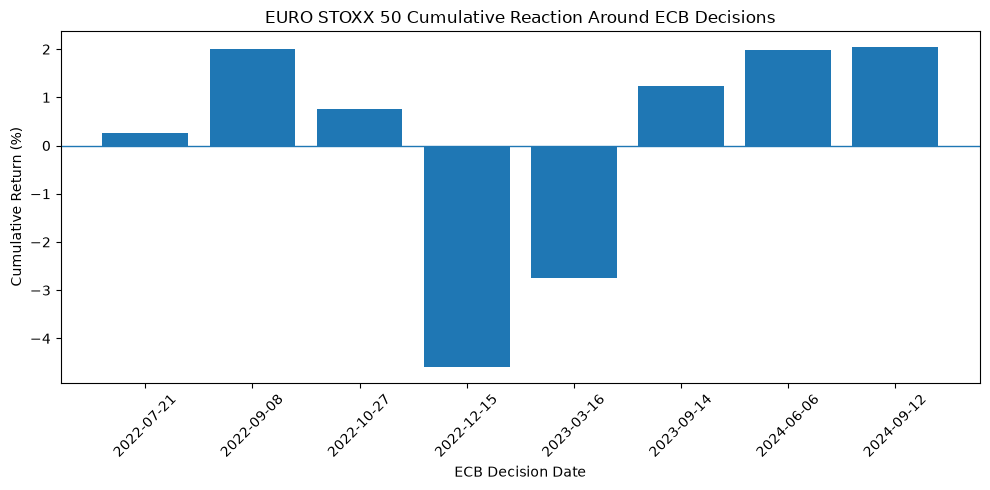

In [67]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    event_study["Date"].dt.strftime("%Y-%m-%d"),
    event_study["EuroStoxx50_Cumulative_%"]
)

ax.axhline(y=0, linewidth=1)

ax.set_title(
    "EURO STOXX 50 Cumulative Reaction Around ECB Decisions"
)

ax.set_ylabel(
    "Cumulative Return (%)"
)

ax.set_xlabel(
    "ECB Decision Date"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### EUR/USD reaction around ECB decisions

The same cumulative event-window approach is applied to EUR/USD.

Positive cumulative returns indicate an appreciation of the euro against the US dollar over the three-day event window, while negative values indicate a depreciation of the euro.

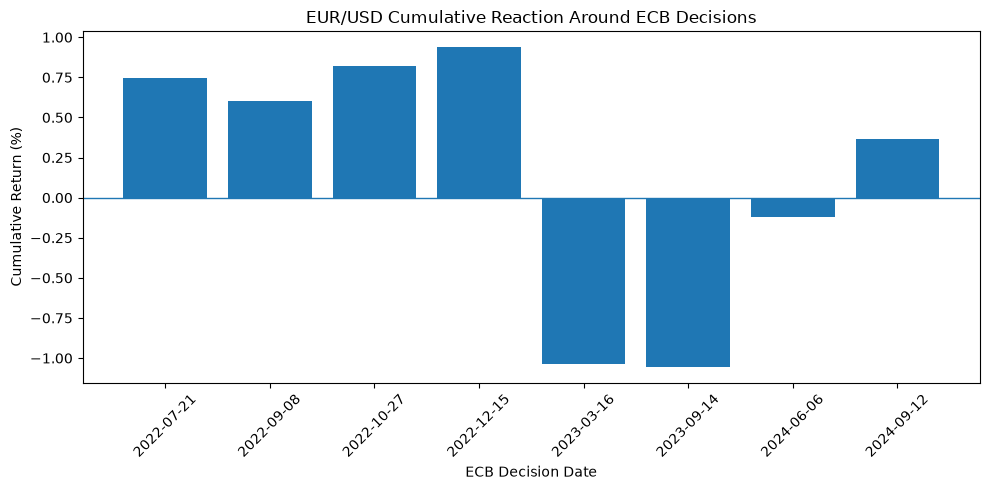

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    event_study["Date"].dt.strftime("%Y-%m-%d"),
    event_study["EURUSD_Cumulative_%"]
)

ax.axhline(y=0, linewidth=1)

ax.set_title(
    "EUR/USD Cumulative Reaction Around ECB Decisions"
)

ax.set_ylabel(
    "Cumulative Return (%)"
)

ax.set_xlabel(
    "ECB Decision Date"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [69]:
event_summary = event_study[[
    "Date",
    "Rate_Change_bps",
    "Event",
    "EuroStoxx50_Cumulative_%",
    "EURUSD_Cumulative_%"
]].copy()

event_summary.round({
    "EuroStoxx50_Cumulative_%": 2,
    "EURUSD_Cumulative_%": 2
})

,Date,Rate_Change_bps,Event,EuroStoxx50_Cumulative_%,EURUSD_Cumulative_%
0,2022-07-21,50,First rate hike of the tightening cycle,0.25,0.75
1,2022-09-08,75,75 bp acceleration in monetary tightening,2.00,0.60
2,2022-10-27,75,Third consecutive major rate increase,0.77,0.82
3,2022-12-15,50,"Slower 50 bp hike, but restrictive guidance",-4.59,0.94
4,2023-03-16,50,50 bp hike amid financial market tensions,-2.74,-1.03
5,2023-09-14,25,Final hike of the tightening cycle,1.24,-1.05
6,2024-06-06,-25,First rate cut after nine months on hold,1.98,-0.12
7,2024-09-12,-25,Second 25 bp cut,2.04,0.37


In [70]:
event_summary["EuroStoxx50_Abs_Reaction"] = (
    event_summary["EuroStoxx50_Cumulative_%"].abs()
)

event_summary["EURUSD_Abs_Reaction"] = (
    event_summary["EURUSD_Cumulative_%"].abs()
)

In [71]:
event_summary.sort_values(
    "EuroStoxx50_Abs_Reaction",
    ascending=False
)[[
    "Date",
    "Event",
    "EuroStoxx50_Cumulative_%",
    "EURUSD_Cumulative_%"
]]


,Date,Event,EuroStoxx50_Cumulative_%,EURUSD_Cumulative_%
3,2022-12-15,"Slower 50 bp hike, but restrictive guidance",-4.585349,0.937437
4,2023-03-16,50 bp hike amid financial market tensions,-2.739109,-1.033813
7,2024-09-12,Second 25 bp cut,2.038887,0.365571
1,2022-09-08,75 bp acceleration in monetary tightening,1.997067,0.600722
6,2024-06-06,First rate cut after nine months on hold,1.977239,-0.118757
5,2023-09-14,Final hike of the tightening cycle,1.244140,-1.053075
2,2022-10-27,Third consecutive major rate increase,0.765286,0.822341
0,2022-07-21,First rate hike of the tightening cycle,0.252270,0.748179


In [72]:
event_summary.sort_values(
    "EURUSD_Abs_Reaction",
    ascending=False
)[[
    "Date",
    "Event",
    "EuroStoxx50_Cumulative_%",
    "EURUSD_Cumulative_%"
]]

,Date,Event,EuroStoxx50_Cumulative_%,EURUSD_Cumulative_%
5,2023-09-14,Final hike of the tightening cycle,1.244140,-1.053075
4,2023-03-16,50 bp hike amid financial market tensions,-2.739109,-1.033813
3,2022-12-15,"Slower 50 bp hike, but restrictive guidance",-4.585349,0.937437
2,2022-10-27,Third consecutive major rate increase,0.765286,0.822341
0,2022-07-21,First rate hike of the tightening cycle,0.252270,0.748179
1,2022-09-08,75 bp acceleration in monetary tightening,1.997067,0.600722
7,2024-09-12,Second 25 bp cut,2.038887,0.365571
6,2024-06-06,First rate cut after nine months on hold,1.977239,-0.118757


### Identifying the strongest market reactions

The event-study results are sorted by the absolute cumulative reaction of the EURO STOXX 50.

This allows us to identify which selected ECB decisions coincided with the largest short-term movements in European equities, while simultaneously comparing the corresponding EUR/USD reaction.

The ranking is based on the magnitude of the equity-market movement, regardless of whether the reaction was positive or negative.

In [73]:
strongest_equity_event = event_summary.loc[
    event_summary["EuroStoxx50_Abs_Reaction"].idxmax()
]

strongest_equity_event

Date                                                2022-12-15 00:00:00
Rate_Change_bps                                                      50
Event                       Slower 50 bp hike, but restrictive guidance
EuroStoxx50_Cumulative_%                                      -4.585349
EURUSD_Cumulative_%                                            0.937437
EuroStoxx50_Abs_Reaction                                       4.585349
EURUSD_Abs_Reaction                                            0.937437
Name: 3, dtype: object

In [74]:
strongest_fx_event = event_summary.loc[
    event_summary["EURUSD_Abs_Reaction"].idxmax()
]

strongest_fx_event

Date                                       2023-09-14 00:00:00
Rate_Change_bps                                             25
Event                       Final hike of the tightening cycle
EuroStoxx50_Cumulative_%                               1.24414
EURUSD_Cumulative_%                                  -1.053075
EuroStoxx50_Abs_Reaction                               1.24414
EURUSD_Abs_Reaction                                   1.053075
Name: 5, dtype: object

In [75]:
event_summary.to_csv(
    "../data/ecb_event_study.csv",
    index=False
)

### Key Findings from the ECB Event Study

The event study shows that market reactions differed substantially across the selected ECB meetings and were not determined simply by whether the ECB raised or lowered interest rates.

The strongest negative EURO STOXX 50 reaction occurred around the December 2022 meeting, with a cumulative return of approximately **-4.6%** over the three-day event window. A significant negative reaction also occurred around the March 2023 meeting (**-2.7%**), which took place during a period of heightened financial-market tensions.

By contrast, the first two rate cuts analyzed in 2024 coincided with positive EURO STOXX 50 cumulative returns of approximately **2.0%**. However, these movements should not be interpreted as evidence that rate cuts necessarily cause equity markets to rise.

EUR/USD reactions were generally smaller than those observed in European equities. The largest movements in the selected sample occurred around the September 2023 and March 2023 meetings, when the euro depreciated by approximately **1.1%** and **1.0%**, respectively, over the event window.

Overall, the results suggest that the direction of an ECB rate decision alone is insufficient to explain short-term market movements. Investor expectations, forward guidance, the macroeconomic environment and other contemporaneous market developments can all influence the reaction of equities and exchange rates around monetary policy announcements.

## Market View and Key Takeaways

The analysis highlights the strong interaction between inflation, monetary policy and financial markets in the Euro Area over the period considered.

The sharp increase in inflation was followed by a substantial shift in ECB monetary policy, with the Deposit Facility Rate moving from negative levels to a restrictive stance. As inflation subsequently declined, the ECB eventually moved toward monetary easing.

European financial markets reacted differently across the monetary policy cycle. Changes in government bond yields affected financial conditions and were associated with changing relationships with equity returns. The rolling correlation analysis also showed that the relationship between EURO STOXX 50 returns and bond yield changes was not stable over time, suggesting that the impact of interest rates on equities depends on the broader macroeconomic environment.

The foreign-exchange analysis showed that ECB policy alone provides only a partial explanation of EUR/USD movements. Considering the ECB-Fed interest-rate differential provides a more appropriate framework, although the relationship remains influenced by additional factors such as economic expectations, inflation dynamics and global risk sentiment.

The ECB event study reinforces this conclusion. Market reactions varied considerably across monetary policy meetings, and similar rate decisions were sometimes associated with very different movements in equities and EUR/USD. This suggests that financial markets respond not only to the direction and size of a policy decision, but also to expectations, forward guidance and the economic environment surrounding the announcement.

Overall, the analysis suggests that monetary policy is an important driver of European financial markets, but its effects cannot be interpreted in isolation. Understanding market movements requires combining macroeconomic conditions, relative monetary policy, investor expectations and cross-asset relationships.